# Explore here

In [2]:
# Your code here
# Paso 1: Importación de librerías

# Paso 1: Importación de librerías
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar el dataset desde la URL
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv"
housing = pd.read_csv(url)

# Ver las primeras filas para inspección
print(housing.head())

# División del dataset (sin estratificar, ya que aún no hay etiquetas)
train_data, test_data = train_test_split(housing, test_size=0.2, random_state=42)

# Verificamos dimensiones
print(f"Train: {train_data.shape}, Test: {test_data.shape}")



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Train: (16512, 9), Test: (4128, 9)


<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16512 non-null  float64
 1   HouseAge     16512 non-null  float64
 2   AveRooms     16512 non-null  float64
 3   AveBedrms    16512 non-null  float64
 4   Population   16512 non-null  float64
 5   AveOccup     16512 non-null  float64
 6   Latitude     16512 non-null  float64
 7   Longitude    16512 non-null  float64
 8   MedHouseVal  16512 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  16512.000000  16512.000000  16512.000000  16512.000000  16512.000000   
mean       3.880754     28.608285      5.435235      1.096685   1426.453004   
std        1.904294     12.602499      2.387375      0.433215   1137.056380   
min        0.499900      1.000000      0.888889      0.333333      3.0

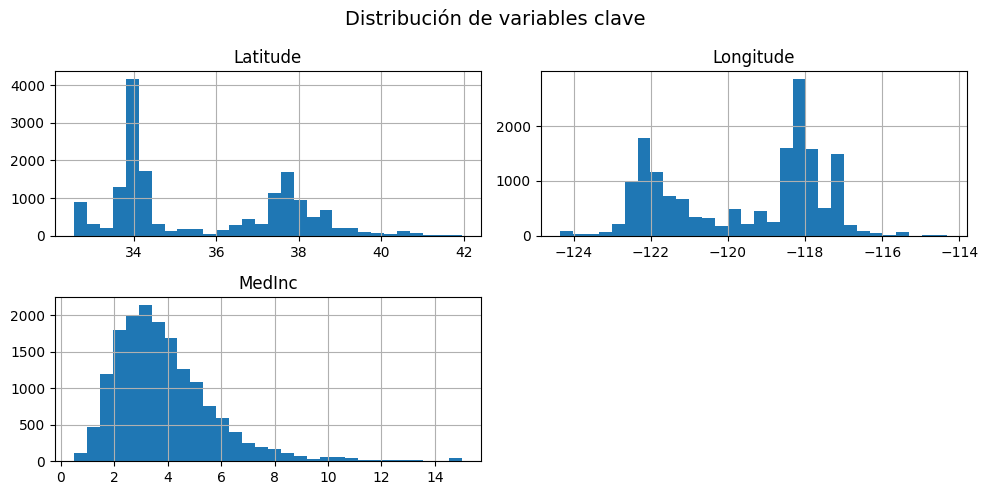

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ver info general del dataset
print(train_data.info())

# Estadísticas descriptivas
print(train_data.describe())

# Verificar nulos
print(train_data.isnull().sum())

# Histograma de las variables relevantes
features = ['Latitude', 'Longitude', 'MedInc']
train_data[features].hist(bins=30, figsize=(10, 5))
plt.suptitle("Distribución de variables clave", fontsize=14)
plt.tight_layout()
plt.show()



In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selección de variables para clustering
features = ['Latitude', 'Longitude', 'MedInc']
X_train = train_data[features]

# Escalar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Aplicar KMeans con 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Guardar los clusters en el dataframe original
train_data['cluster'] = clusters

# Ver primeras filas con el cluster asignado
print(train_data[['Latitude', 'Longitude', 'MedInc', 'cluster']].head())


       Latitude  Longitude  MedInc  cluster
14196     32.71    -117.03  3.2596        5
8267      33.77    -118.16  3.8125        5
17445     34.66    -120.48  4.1563        0
14265     32.69    -117.11  1.9425        5
2271      36.78    -119.80  3.5542        0


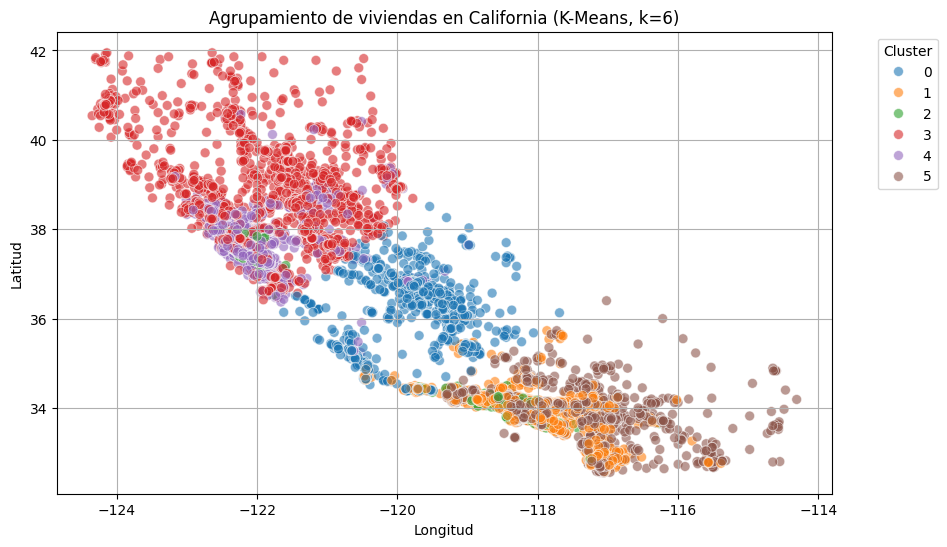

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Mapa de puntos coloreados por cluster
sns.scatterplot(
    data=train_data,
    x='Longitude', y='Latitude',
    hue='cluster',
    palette='tab10',  # 10 colores distintos, suficientes para 6 clusters
    alpha=0.6,
    s=50  # tamaño del punto
)

plt.title("Agrupamiento de viviendas en California (K-Means, k=6)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()


 Interpretación del clustering:
 
Se formaron agrupamientos geográficos claros: zonas norte, centro y sur de California.

Algunas zonas con alta densidad de puntos están diferenciadas — probablemente por diferencias en el ingreso medio (MedInc), como queríamos.

La separación en 6 clusters parece razonable para capturar la diversidad de regiones + niveles socioeconómicos.

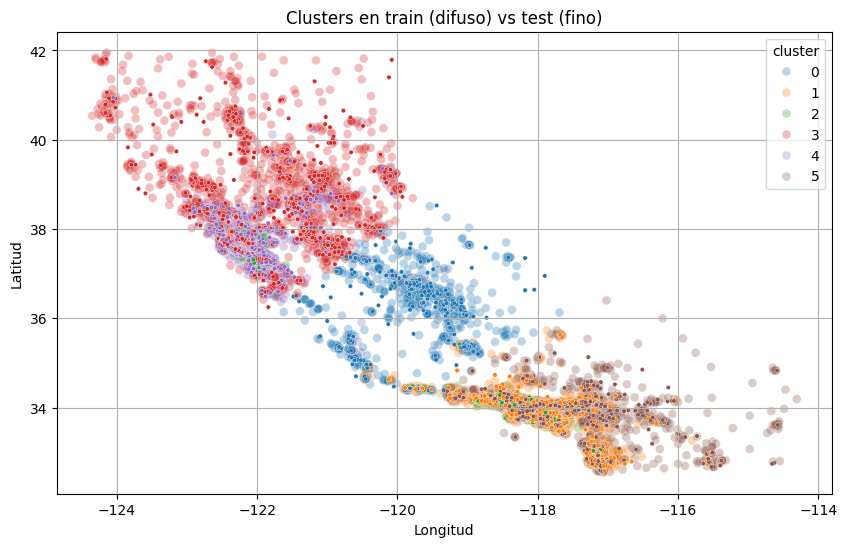

In [9]:
# Seleccionamos y escalamos las mismas columnas del test set
X_test = test_data[['Latitude', 'Longitude', 'MedInc']]
X_test_scaled = scaler.transform(X_test)

# Predecimos los clusters con el modelo entrenado
test_data['cluster'] = kmeans.predict(X_test_scaled)

plt.figure(figsize=(10, 6))

# Train: más transparente y más grande
sns.scatterplot(
    data=train_data,
    x='Longitude', y='Latitude',
    hue='cluster', palette='tab10',
    alpha=0.3, s=40
)

# Test: más pequeño y opaco para destacar diferencias
sns.scatterplot(
    data=test_data,
    x='Longitude', y='Latitude',
    hue='cluster', palette='tab10',
    alpha=1.0, s=10, legend=False  # No repetimos leyenda
)

plt.title("Clusters en train (difuso) vs test (fino)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()



Observaciones:

Los puntos de test (más pequeños y opacos) encajan perfectamente en los patrones espaciales creados por train.

No hay clusters nuevos o erráticos: los límites se mantienen consistentes.

Esto valida que el modelo no supervisado está segmentando bien el espacio geográfico según el ingreso medio (MedInc).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Definimos las variables para el modelo supervisado
features_sup = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
X_train_sup = train_data[features_sup]
y_train_sup = train_data['cluster']

X_test_sup = test_data[features_sup]
y_test_sup = test_data['cluster']

# Entrenamos el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sup, y_train_sup)

# Predicciones y evaluación
y_pred = rf.predict(X_test_sup)
print(classification_report(y_test_sup, y_pred))


              precision    recall  f1-score   support

           0       0.58      0.39      0.47       337
           1       0.55      0.62      0.58       829
           2       0.78      0.68      0.73       112
           3       0.54      0.55      0.54       962
           4       0.49      0.38      0.43       514
           5       0.67      0.72      0.69      1374

    accuracy                           0.59      4128
   macro avg       0.60      0.56      0.57      4128
weighted avg       0.59      0.59      0.59      4128



 Evaluación del modelo supervisado (RandomForestClassifier):

Accuracy general: 59%

Es aceptable considerando que estamos prediciendo 6 clases y que estas etiquetas fueron generadas automáticamente con K-Means.

Cluster 2 y 5: Se predicen bastante bien (F1 ≈ 0.7+).

Posiblemente tienen patrones claros en variables como HouseAge, AveRooms, etc.

Cluster 0 y 4: Tienen más confusión (F1 ≈ 0.43–0.47).

Puede deberse a solapamiento en características no espaciales.

Macro avg ≈ 0.57: Promedio equitativo entre clases → hay algo de desbalance o diferencia de dificultad.



/tmp/ipykernel_4313/2624081532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='Blues_d')


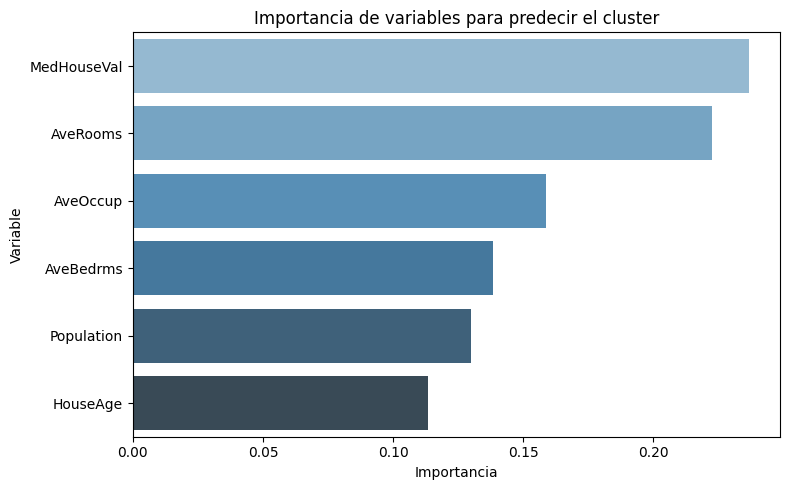

       feature  importance
5  MedHouseVal    0.236777
1     AveRooms    0.222588
4     AveOccup    0.158779
2    AveBedrms    0.138353
3   Population    0.130074
0     HouseAge    0.113430


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Obtener importancia de características
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features_sup,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Mostrar como gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='Blues_d')
plt.title("Importancia de variables para predecir el cluster")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# También mostramos la tabla
print(feature_importance_df)


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Entrenamiento del modelo con los mismos datos
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=6,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train_sup, y_train_sup)

# Predicción y evaluación
y_pred_xgb = xgb_model.predict(X_test_sup)
print("=== XGBoost Classification Report ===")
print(classification_report(y_test_sup, y_pred_xgb))


/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:05:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.59      0.42      0.49       337
           1       0.54      0.62      0.58       829
           2       0.75      0.70      0.72       112
           3       0.53      0.54      0.53       962
           4       0.45      0.36      0.40       514
           5       0.67      0.70      0.68      1374

    accuracy                           0.58      4128
   macro avg       0.59      0.56      0.57      4128
weighted avg       0.58      0.58      0.58      4128



Comparativa:

Modelo	            Accuracy	            F1 Promedio Ponderado

Random Forest	    0.59	                     0.59

XGBoost (default)	0.58	                     0.58

In [13]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Definimos el modelo base
xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Definimos el grid de parámetros
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# GridSearch con 3-fold CV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Entrenamiento
grid_search.fit(X_train_sup, y_train_sup)

# Mejores parámetros encontrados
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

# Evaluación en test
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_sup)
print("\n=== XGBoost (optimizado) ===")
print(classification_report(y_test_sup, y_pred_best))


Fitting 3 folds for each of 24 candidates, totalling 72 fits


/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:09:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:09:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:09:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:09:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not use

Mejores hiperparámetros:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

=== XGBoost (optimizado) ===
              precision    recall  f1-score   support

           0       0.56      0.40      0.47       337
           1       0.54      0.65      0.59       829
           2       0.71      0.72      0.72       112
           3       0.53      0.53      0.53       962
           4       0.45      0.32      0.38       514
           5       0.67      0.71      0.69      1374

    accuracy                           0.58      4128
   macro avg       0.58      0.56      0.56      4128
weighted avg       0.58      0.58      0.57      4128



| Modelo                 | Accuracy | Weighted F1 |
|------------------------|----------|-------------|
| Random Forest          | 0.59     | 0.59        |
| XGBoost (sin tuning)   | 0.58     | 0.58        |
| **XGBoost (optimizado)** | **0.58** | **0.57**    |

El tuning no mejoró significativamente el rendimiento, lo cual sugiere que el límite está en la calidad del cluster asignado por K-Means (etiqueta generada), no tanto en el modelo.

Cluster 2 y 5 siguen siendo los mejor clasificados, lo que indica que son clases más definidas en el espacio de variables.

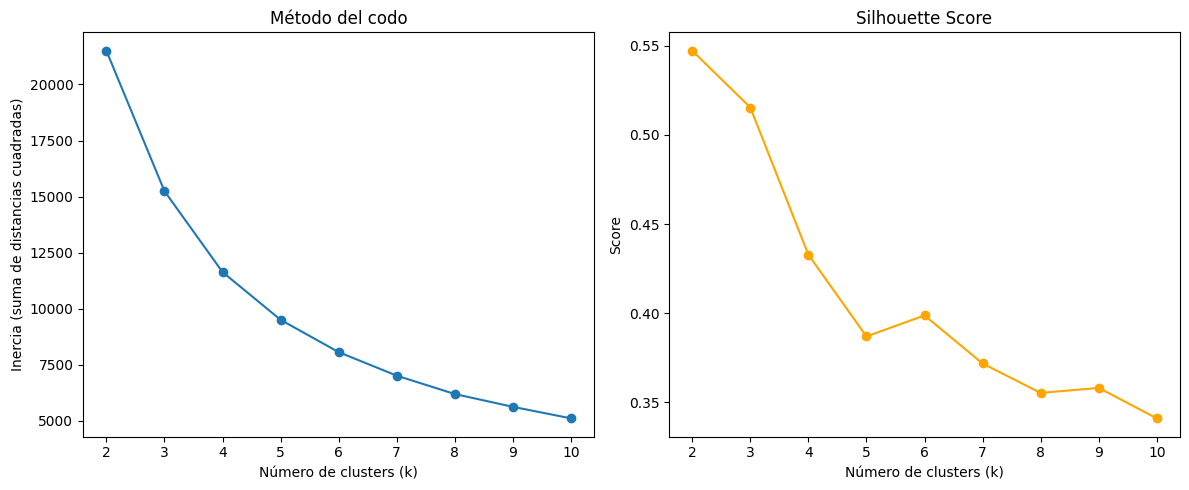

In [14]:
#valuación de k con el método del codo y Silhouette Score

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Usamos los datos escalados del entrenamiento original
X = scaler.transform(train_data[['Latitude', 'Longitude', 'MedInc']])

# Probamos diferentes valores de k
k_range = range(2, 11)
inertia = []
silhouette = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, model.labels_))

# Plot del método del codo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (suma de distancias cuadradas)')

# Plot del Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


Método del codo:

El “codo” más claro aparece alrededor de k = 4 o 5.

Después de eso, la mejora en inercia es cada vez menor (ley de rendimientos decrecientes).

Silhouette Score:

El score más alto está en k = 2, seguido de k = 3 y luego cae abruptamente.

A partir de k = 5 en adelante, los scores son bajos y estables, lo que indica clusters menos cohesionados o solapados.

Conclusión

El clustering original con k=6 puede estar sobreajustado, dividiendo demasiado el espacio.

k=3 o k=4 parecen más naturales y estables, según ambas métricas.

Reentrenar KMeans con k=4

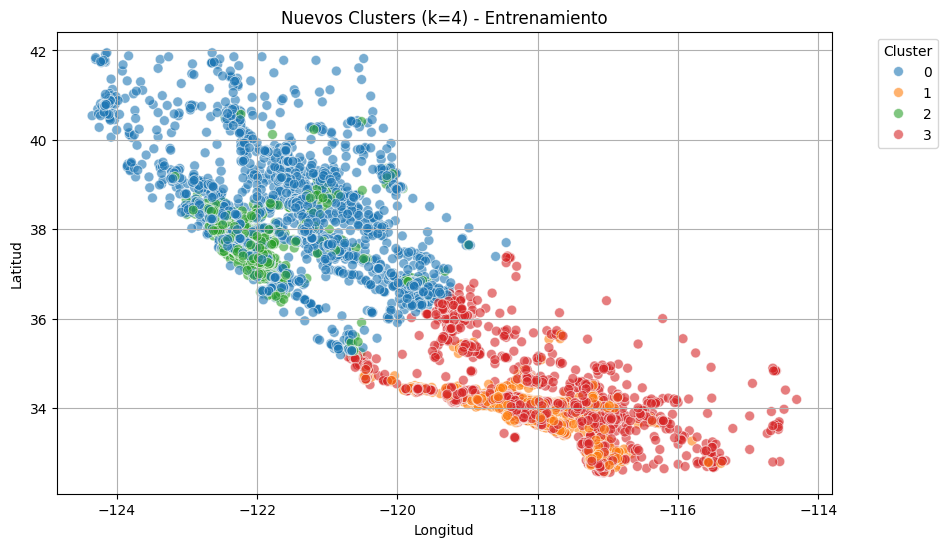

In [15]:
# Reentrenar KMeans con k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
train_data['cluster'] = kmeans_4.fit_predict(X)

# Visualizar los nuevos clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train_data,
    x='Longitude', y='Latitude',
    hue='cluster', palette='tab10',
    alpha=0.6, s=50
)
plt.title("Nuevos Clusters (k=4) - Entrenamiento")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


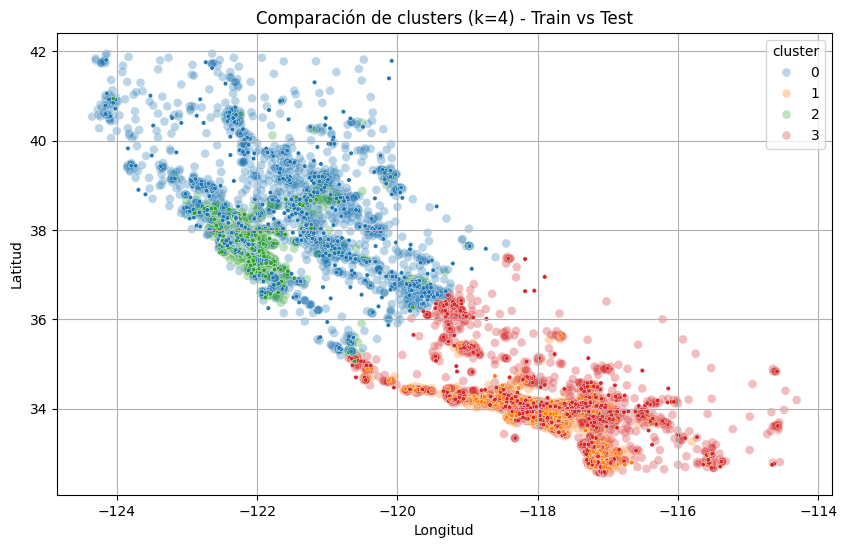

In [16]:
# Seleccionar las variables para el clustering
X_test = scaler.transform(test_data[['Latitude', 'Longitude', 'MedInc']])

# Asignar los nuevos clusters (k=4) al conjunto de prueba
test_data['cluster'] = kmeans_4.predict(X_test)

# Visualización de los clusters en el conjunto test
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train_data,
    x='Longitude', y='Latitude',
    hue='cluster', palette='tab10',
    alpha=0.3, s=40
)
sns.scatterplot(
    data=test_data,
    x='Longitude', y='Latitude',
    hue='cluster', palette='tab10',
    alpha=1.0, s=10, legend=False
)
plt.title("Comparación de clusters (k=4) - Train vs Test")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()


In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Redefinimos los datos supervisados con los nuevos clusters (k=4)
features_sup = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
X_train_sup = train_data[features_sup]
y_train_sup = train_data['cluster']

X_test_sup = test_data[features_sup]
y_test_sup = test_data['cluster']

# Entrenar modelo XGBoost con 4 clases
xgb_final = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)
xgb_final.fit(X_train_sup, y_train_sup)

# Evaluación
y_pred_final = xgb_final.predict(X_test_sup)
print("=== XGBoostClassifier (con k=4) ===")
print(classification_report(y_test_sup, y_pred_final))


/workspaces/Rene_Proyecto-Tutorial-K-Medias/ven/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:23:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoostClassifier (con k=4) ===
              precision    recall  f1-score   support

           0       0.62      0.59      0.60      1262
           1       0.55      0.60      0.57       620
           2       0.44      0.38      0.41       440
           3       0.67      0.70      0.69      1806

    accuracy                           0.62      4128
   macro avg       0.57      0.57      0.57      4128
weighted avg       0.61      0.62      0.61      4128



Comparación resumida

Modelo	Clusters	    Accuracy	    Weighted F1


XGBoost (antes)	6	    0.58	          0.58


XGBoost (nuevo)	4	    0.62	          0.61

Conclusión 

El cambio a k=4 mejoró tanto la coherencia del clustering como la capacidad de predicción del modelo supervisado.

Los clusters ahora son más distinguibles en el espacio de variables como AveRooms, MedHouseVal, etc.

Esto valida la importancia de evaluar y optimizar k, incluso cuando el flujo original sugería un valor arbitrario como 6.